[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aubreycoffey/single-cell-analysis-pipeline/blob/main/notebooks/01_preprocessing.ipynb)

# Notebook 1: Preprocessing

This notebook covers the first steps of a standard scRNA-seq workflow:
- Loading the PBMC 3k dataset
- Quality control (QC) filtering
- Normalization and log transformation
- Highly variable gene (HVG) selection
- Saving the processed AnnData object for downstream notebooks

## Google Drive setup

Mount Drive to persist data between notebook sessions. All `.h5ad` files will be saved to `MyDrive/scrnaseq-pbmc-pipeline-data/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DATA_DIR = '/content/drive/MyDrive/scrnaseq-pbmc-pipeline-data'
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Data directory: {DATA_DIR}')

Mounted at /content/drive
Data directory: /content/drive/MyDrive/scrnaseq-pbmc-pipeline-data


In [2]:
# Install dependencies (Colab only — skip if running locally)
import sys
!{sys.executable} -m pip install -q scanpy leidenalg python-igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 996.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2

In [3]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.figdir = './figures/'
sc.settings.set_figure_params(dpi=100, facecolor='white')
print(f'Scanpy version: {sc.__version__}')

Scanpy version: 1.12.1


/tmp/ipykernel_3423/4256957649.py:7: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor='white')
/tmp/ipykernel_3423/4256957649.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f'Scanpy version: {sc.__version__}')


## 1. Load data

We use the built-in PBMC 3k dataset from 10x Genomics — 2,700 PBMCs sequenced on the Chromium platform.

In [4]:
adata = sc.datasets.pbmc3k()
print(adata)
print(f'\nCells: {adata.n_obs}, Genes: {adata.n_vars}')

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

Cells: 2700, Genes: 32738


## 2. Quality control

We compute three standard QC metrics per cell:
- `n_genes_by_counts` — number of genes detected
- `total_counts` — total UMI counts (how many total transcript molecules, RNA copies, were captured)
- `pct_counts_mt` — fraction of counts from mitochondrial genes (a proxy for cell stress/death)

Cells with very few genes, very high counts, or high mitochondrial fraction are filtered out.

In [5]:
# Annotate mitochondrial genes (human: prefix 'MT-')
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print('QC metrics computed. Summary:')
print(adata.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe().round(2))

QC metrics computed. Summary:
       n_genes_by_counts  total_counts  pct_counts_mt
count            2700.00       2700.00        2700.00
mean              846.99       2366.90           2.22
std               282.10       1094.26           1.17
min               212.00        548.00           0.00
25%               690.00       1757.75           1.54
50%               817.00       2197.00           2.03
75%               953.25       2763.00           2.64
max              3422.00      15844.00          22.57


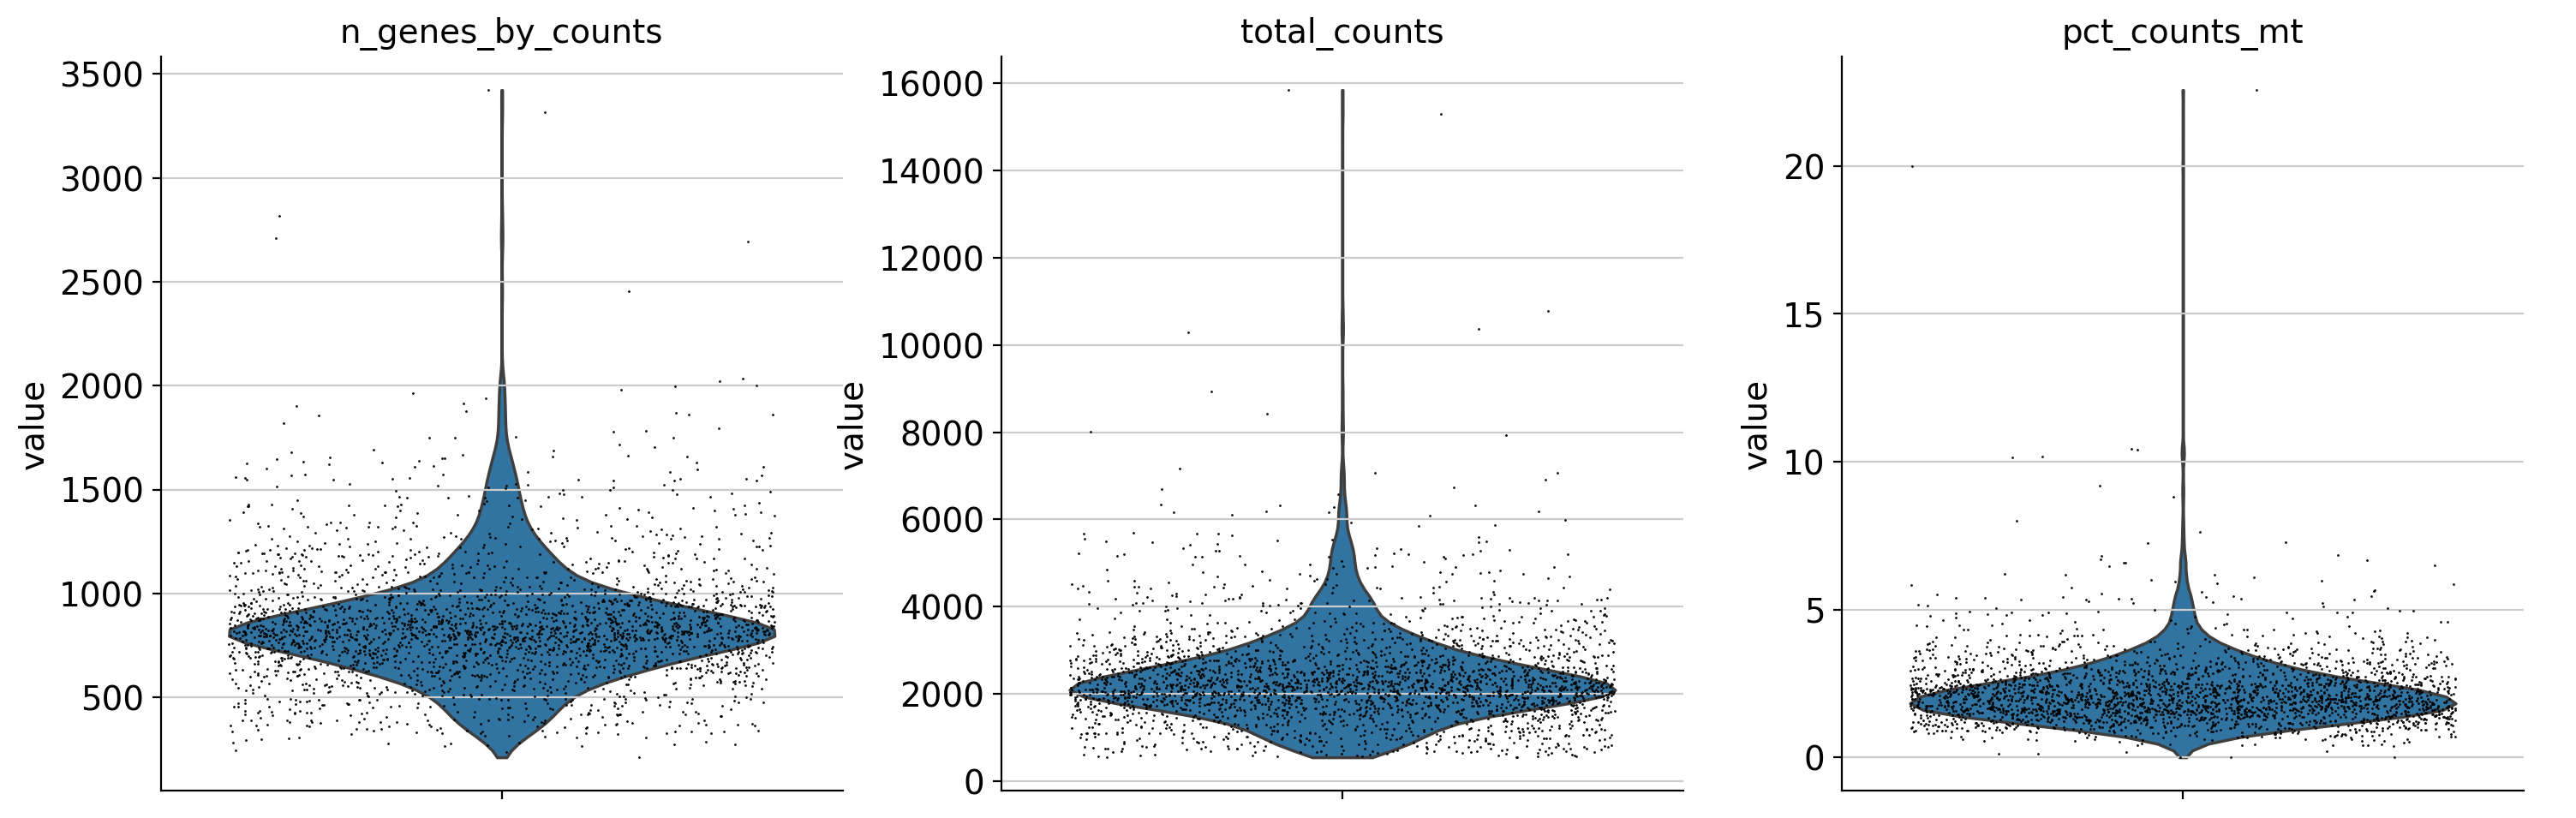

In [6]:
# Visualize QC distributions
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

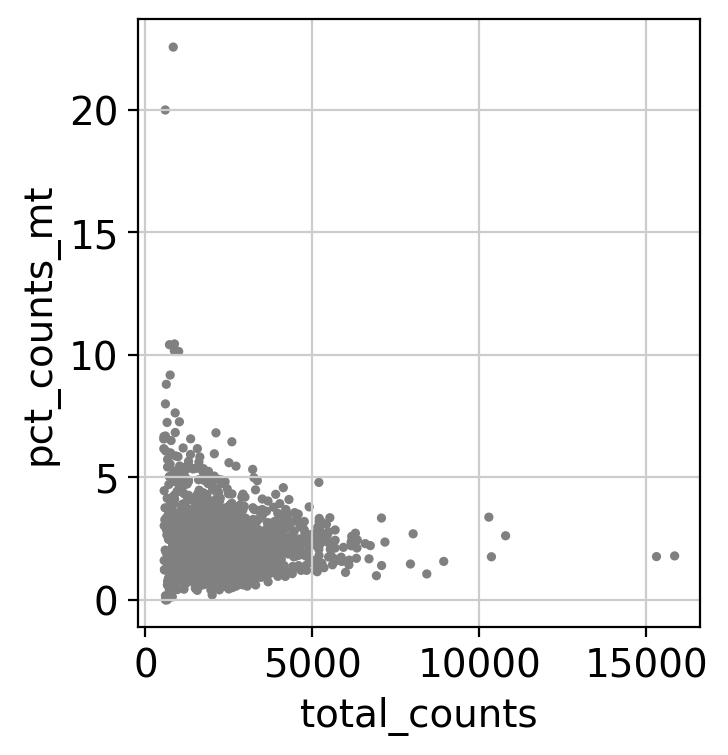

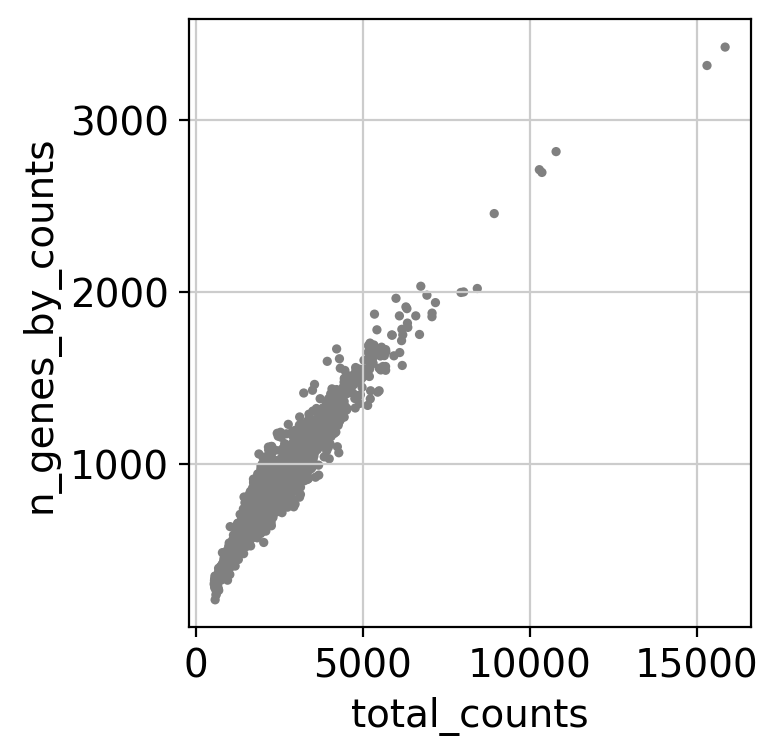

In [7]:
# Scatter plots to spot outliers
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

### Filter thresholds

Based on the distributions above we apply standard PBMC thresholds:
- Remove cells with fewer than 200 or more than 2500 genes detected
- Remove cells with >5% mitochondrial counts
- Remove genes detected in fewer than 3 cells

In [8]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=2500)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

print(f'After filtering — Cells: {adata.n_obs}, Genes: {adata.n_vars}')

After filtering — Cells: 2638, Genes: 13673


## 3. Normalization

We normalize each cell to a total count of 10,000 (counts per 10k), then apply a log1p transform to stabilize variance. The raw counts are stored in `adata.layers['counts']` for later use in differential expression.

In [9]:
# Store raw counts before normalization
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Freeze the normalized+log expression as 'raw' for DE testing later
adata.raw = adata
print('Normalization complete. adata.raw saved.')

Normalization complete. adata.raw saved.


## 4. Highly variable gene selection

We identify the top 2000 highly variable genes (HVGs) — genes whose expression varies meaningfully across cells. Downstream analyses (PCA, clustering) use only these genes to reduce noise and computation.

HVGs identified: 1830 / 13673 genes


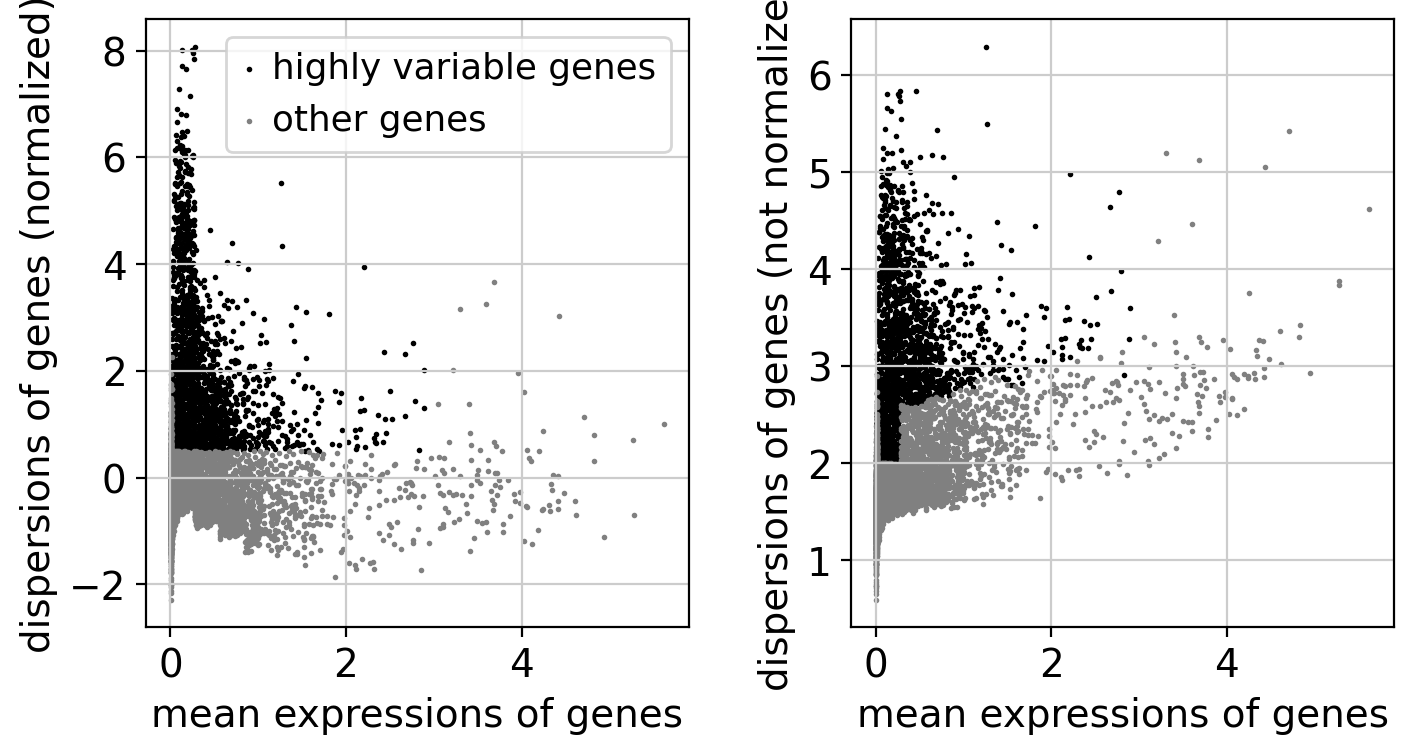

In [10]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f'HVGs identified: {adata.var.highly_variable.sum()} / {adata.n_vars} genes')
sc.pl.highly_variable_genes(adata)

In [11]:
# Subset to HVGs for downstream analysis
adata = adata[:, adata.var.highly_variable].copy()
print(f'AnnData after HVG subset: {adata}')

AnnData after HVG subset: AnnData object with n_obs × n_vars = 2638 × 1830
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


## 5. Scaling

We scale each gene to zero mean and unit variance (capped at max_value=10 to reduce the influence of outliers). This is standard before PCA.

In [12]:
sc.pp.scale(adata, max_value=10)
print('Scaling complete.')

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Scaling complete.


## 6. Save

Save the preprocessed AnnData object. Subsequent notebooks load this file.

In [13]:
import os
os.makedirs('../data', exist_ok=True)
adata.write(f'{DATA_DIR}/pbmc_preprocessed.h5ad')
print('Saved to ../data/pbmc_preprocessed.h5ad')

Saved to ../data/pbmc_preprocessed.h5ad
